# 02 - Preprocessing Pipeline


**Goal of this notebook:**
- Load the train/val/test CSV splits from `01_eda.ipynb`
- Resize all images to 224x224 (required by ViT-Small/16, the I-JEPA encoder)
- Compute dataset-specific mean and std for normalization
- Define augmentation pipelines (train vs val/test)
- Implement the reusable PyTorch `LIDCDataset` class and `DataLoader`
- Run sanity checks on batches before training
- Save `config.json`, `dataset.py`, `loaders.py` to Drive

### Environment Setup

In [1]:
# Pas de montage Google Drive — chemins locaux
# (Cette cellule remplace 'from google.colab import drive')
print('Environnement local détecté — pas de montage nécessaire.')


Environnement local détecté — pas de montage nécessaire.


In [2]:
import subprocess, sys
pkgs = ['torch', 'torchvision', 'timm', 'einops', 'albumentations',
        'matplotlib', 'seaborn', 'tqdm', 'pandas', 'numpy', 'Pillow', 'scikit-learn']
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs)
print('Installation terminée.')


Installation terminée.


In [3]:
import os

# Modifiez ROOT si nécessaire (par défaut : sous-dossier 'PFA' à côté du notebook)
ROOT      = os.environ.get('PROJECT_ROOT') or (os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()).lower() == 'notebooks' else os.getcwd()) 
DATA_PROC = os.path.join(ROOT, 'data', 'processed')
DATA_TENS = os.path.join(ROOT, 'data', 'tensors')
FIGURES   = os.path.join(ROOT, 'results', 'figures', 'preprocessing')
SRC       = os.path.join(ROOT, 'src')

for d in [DATA_TENS, FIGURES, SRC]:
    os.makedirs(d, exist_ok=True)

print('Checking splits from 01_eda...')
for split in ['train.csv', 'val.csv', 'test.csv']:
    p = os.path.join(DATA_PROC, split)
    print(f'  {split}: {"OK" if os.path.exists(p) else "MISSING - run 01_eda.ipynb first"}')


Checking splits from 01_eda...
  train.csv: OK
  val.csv: OK
  test.csv: OK


### 1. Imports & Configuration

In [5]:
!pip install optree

In [7]:
import json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import albumentations as A
from albumentations.pytorch import ToTensorV2

SEED        = 42
IMG_SIZE    = 224
BATCH_SIZE  = 16
NUM_WORKERS = 0

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU   : {torch.cuda.get_device_name(0)}')
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device: cuda
GPU   : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM  : 8.6 GB


### 2. Load CSV Splits

In [8]:
train_df = pd.read_csv(os.path.join(DATA_PROC, 'train.csv'))
val_df   = pd.read_csv(os.path.join(DATA_PROC, 'val.csv'))
test_df  = pd.read_csv(os.path.join(DATA_PROC, 'test.csv'))

for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    c0 = int((df['label'] == 0).sum())
    c1 = int((df['label'] == 1).sum())
    print(f'{name:6}: {len(df):5} images  |  class 0: {c0}  class 1: {c1}')

Train : 14302 images  |  class 0: 7204  class 1: 7098
Val   :  3065 images  |  class 0: 1544  class 1: 1521
Test  :  3065 images  |  class 0: 1544  class 1: 1521


### 3. Compute Dataset Mean & Std

Computed on the **training set only** — never leak val/test statistics.

In [9]:
def compute_mean_std(df, img_size=IMG_SIZE, sample_n=500):
    sample = df.sample(n=min(sample_n, len(df)), random_state=SEED)
    ch_sum  = np.zeros(3)
    ch_sum2 = np.zeros(3)
    count   = 0
    for _, row in tqdm(sample.iterrows(), total=len(sample), desc='Computing stats'):
        try:
            img = Image.open(row['path']).convert('RGB').resize((img_size, img_size))
            arr = np.array(img, dtype=np.float32) / 255.0
            ch_sum  += arr.mean(axis=(0, 1))
            ch_sum2 += (arr ** 2).mean(axis=(0, 1))
            count += 1
        except Exception:
            pass
    mean = ch_sum  / count
    std  = np.sqrt(ch_sum2 / count - mean ** 2)
    return mean, std

MEAN, STD = compute_mean_std(train_df)
print(f'Dataset mean (R,G,B): {MEAN.round(4)}')
print(f'Dataset std  (R,G,B): {STD.round(4)}')
print('ImageNet mean ref   : [0.485, 0.456, 0.406]')
print('ImageNet std  ref   : [0.229, 0.224, 0.225]')

Computing stats: 100%|███████████████████████████████████████████████████████████████| 500/500 [00:05<00:00, 99.48it/s]

Dataset mean (R,G,B): [0.2731 0.2731 0.2731]
Dataset std  (R,G,B): [0.2402 0.2402 0.2402]
ImageNet mean ref   : [0.485, 0.456, 0.406]
ImageNet std  ref   : [0.229, 0.224, 0.225]


In [10]:
stats_path = os.path.join(DATA_PROC, 'dataset_stats.json')
with open(stats_path, 'w') as f:
    json.dump({'mean': MEAN.tolist(), 'std': STD.tolist()}, f, indent=2)
print(f'Saved: {stats_path}')

Saved: C:/Users/uranu/DESKTOP_V2.0/ENSIAS/2A/S4/PFA\data\processed\dataset_stats.json


### 4. Augmentation Pipelines

- **train_transform** — aggressive augmentation to prevent overfitting
- **val_transform** — resize + normalize only (no randomness)
- **viz_transform** — resize only, for plotting raw images

In [11]:
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    T.ToTensor(),
    T.Normalize(mean=MEAN.tolist(), std=STD.tolist()),
])

val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=MEAN.tolist(), std=STD.tolist()),
])

viz_transform = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE))])

print('train_transform: resize + horizontal flip + rotate + jitter + affine + normalize')
print('val_transform  : resize + normalize only')
print('viz_transform  : resize only (for plots)')

train_transform: resize + horizontal flip + rotate + jitter + affine + normalize
val_transform  : resize + normalize only
viz_transform  : resize only (for plots)


In [13]:
albu_train = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.GaussNoise(std_range=(0.01, 0.02), p=0.3),
    A.CLAHE(clip_limit=2.0, p=0.3),
    A.Normalize(mean=MEAN.tolist(), std=STD.tolist()),
    ToTensorV2(),
])

albu_val = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=MEAN.tolist(), std=STD.tolist()),
    ToTensorV2(),
])

print('Albumentations transforms ready.')

Albumentations transforms ready.


### 5. PyTorch Dataset Class

A single reusable `LIDCDataset` class — defined here and saved to `src/dataset.py`.

In [14]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class LIDCDataset(Dataset):
    def __init__(self, df, transform=None, use_albumentations=False, pretrain=False):
        self.df                 = df.reset_index(drop=True)
        self.transform          = transform
        self.use_albumentations = use_albumentations
        self.pretrain           = pretrain
        if not pretrain:
            self.labels = torch.tensor(df['label'].values, dtype=torch.long)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        import random
        from PIL import UnidentifiedImageError
        import numpy as np

        row = self.df.iloc[idx]
        try:
            image = Image.open(row['path']).convert('RGB')
        except (UnidentifiedImageError, OSError, FileNotFoundError):
            print(f"\nSkipping corrupted image: {row['path']}")
            # If the image is broken, randomly pick another index to keep the batch size constant
            random_idx = random.randint(0, len(self.df) - 1)
            return self.__getitem__(random_idx)

        if self.transform is not None:
            if self.use_albumentations:
                aug   = self.transform(image=np.array(image))
                image = aug['image']
            else:
                image = self.transform(image)

        if self.pretrain:
            return image
        return image, self.labels[idx]

    def get_class_weights(self):
        cw = compute_class_weight('balanced', classes=np.array([0,1]),
                               y=self.labels.numpy())
        return torch.tensor(cw, dtype=torch.float32)

print('LIDCDataset class ready.')

LIDCDataset class ready.


In [15]:
# Save dataset.py to Drive/src/
src_code = '''
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset
from sklearn.utils.class_weight import compute_class_weight

class LIDCDataset(Dataset):
    def __init__(self, df, transform=None, use_albumentations=False, pretrain=False):
        self.df                 = df.reset_index(drop=True)
        self.transform          = transform
        self.use_albumentations = use_albumentations
        self.pretrain           = pretrain
        if not pretrain:
            self.labels = torch.tensor(df['label'].values, dtype=torch.long)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        import random
        from PIL import UnidentifiedImageError
        import numpy as np

        row = self.df.iloc[idx]
        try:
            image = Image.open(row['path']).convert('RGB')
        except (UnidentifiedImageError, OSError, FileNotFoundError):
            print(f"\nSkipping corrupted image: {row['path']}")
            # If the image is broken, randomly pick another index to keep the batch size constant
            random_idx = random.randint(0, len(self.df) - 1)
            return self.__getitem__(random_idx)

        if self.transform is not None:
            if self.use_albumentations:
                aug   = self.transform(image=np.array(image))
                image = aug['image']
            else:
                image = self.transform(image)

        if self.pretrain:
            return image
        return image, self.labels[idx]

    def get_class_weights(self):
        cw = compute_class_weight('balanced', classes=np.array([0,1]),
                               y=self.labels.numpy())
        return torch.tensor(cw, dtype=torch.float32)
'''
with open(os.path.join(SRC, 'dataset.py'), 'w') as f:
    f.write(src_code)
print('Saved: src/dataset.py')

Saved: src/dataset.py


### 6. Build DataLoaders

In [16]:
train_dataset = LIDCDataset(train_df, transform=train_transform)
val_dataset   = LIDCDataset(val_df,   transform=val_transform)
test_dataset  = LIDCDataset(test_df,  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

class_weight = train_dataset.get_class_weights()

print(f'Train batches : {len(train_loader)}  ({len(train_dataset)} images)')
print(f'Val   batches : {len(val_loader)}  ({len(val_dataset)} images)')
print(f'Test  batches : {len(test_loader)}  ({len(test_dataset)} images)')
print(f'Batch size    : {BATCH_SIZE}')
print(f'class_weights   : {[round(w, 4) for w in class_weight.tolist()]}')

Train batches : 893  (14302 images)
Val   batches : 192  (3065 images)
Test  batches : 192  (3065 images)
Batch size    : 16
class_weights   : [0.9926, 1.0075]


### 7. Sanity Checks

In [17]:
images, labels = next(iter(train_loader))

print('Batch tensor info:')
print(f'  images shape : {images.shape}  -> (batch, C, H, W)')
print(f'  labels shape : {labels.shape}')
print(f'  dtype        : {images.dtype}')
print(f'  pixel min    : {images.min():.4f}')
print(f'  pixel max    : {images.max():.4f}')
print(f'  pixel mean   : {images.mean():.4f}  (should be ~0 after normalize)')
print(f'  class 0 in batch: {int((labels==0).sum())}')
print(f'  class 1 in batch: {int((labels==1).sum())}')

Batch tensor info:
  images shape : torch.Size([16, 3, 224, 224])  -> (batch, C, H, W)
  labels shape : torch.Size([16])
  dtype        : torch.float32
  pixel min    : -1.1369
  pixel max    : 3.0259
  pixel mean   : 0.1339  (should be ~0 after normalize)
  class 0 in batch: 5
  class 1 in batch: 11


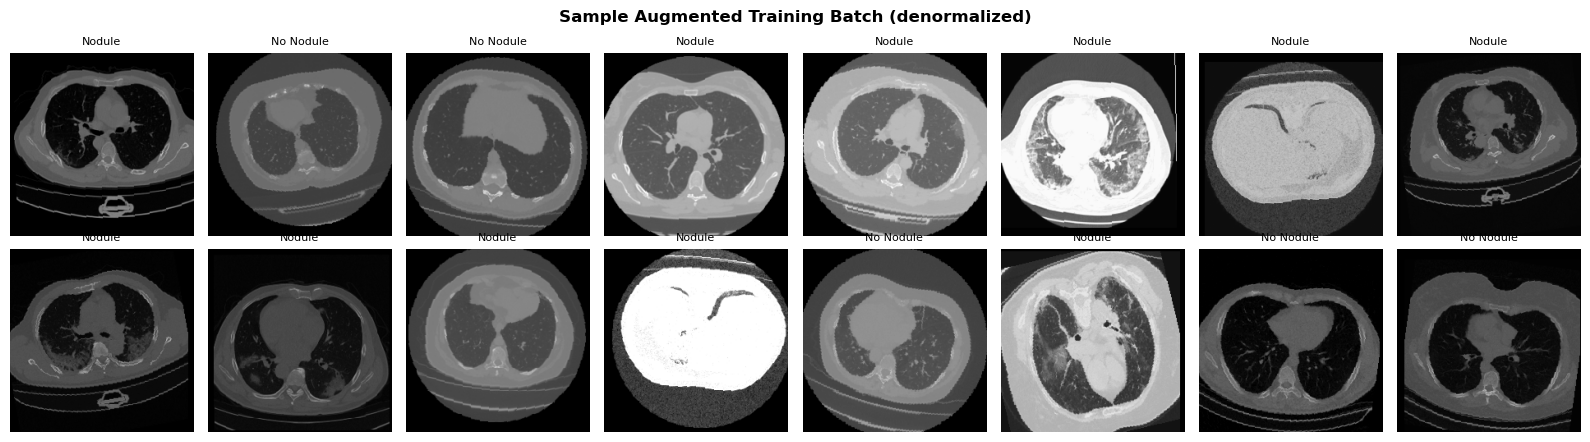

In [18]:
def denormalize(tensor, mean, std):
    t = tensor.clone()
    for c, (m, s) in enumerate(zip(mean, std)):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)

CLASS_NAMES = {0: 'No Nodule', 1: 'Nodule'}
n_show = min(16, BATCH_SIZE)
fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
axes = axes.flatten()

for i in range(n_show):
    img_vis = denormalize(images[i], MEAN, STD).permute(1, 2, 0).numpy()
    axes[i].imshow(img_vis, cmap='gray')
    axes[i].set_title(CLASS_NAMES[int(labels[i].item())], fontsize=8)
    axes[i].axis('off')
for ax in axes[n_show:]:
    ax.axis('off')

plt.suptitle('Sample Augmented Training Batch (denormalized)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'augmented_batch.png'), dpi=150, bbox_inches='tight')
plt.show()

### 8. Raw vs Augmented Comparison

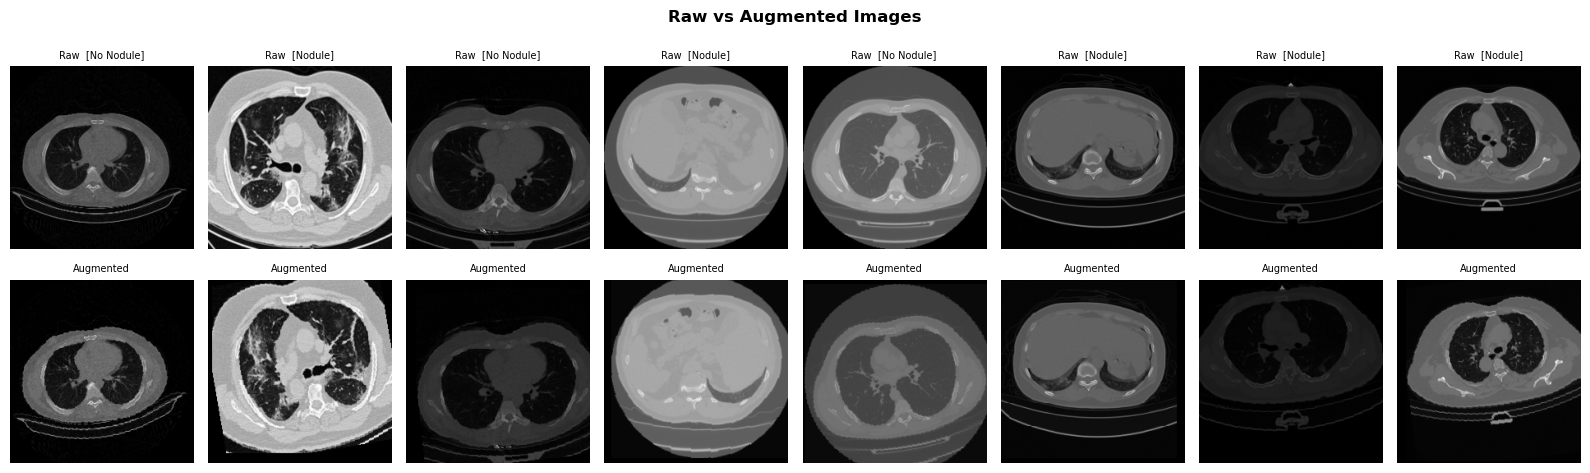

In [19]:
raw_ds = LIDCDataset(train_df.head(8), transform=viz_transform)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))

for i in range(8):
    raw_img, _   = raw_ds[i]
    aug_img, lbl = train_dataset[i]

    axes[0, i].imshow(np.array(raw_img), cmap='gray')
    axes[0, i].set_title(f'Raw  [{CLASS_NAMES[int(lbl)]}]', fontsize=7)
    axes[0, i].axis('off')

    aug_vis = denormalize(aug_img, MEAN, STD).permute(1, 2, 0).numpy()
    axes[1, i].imshow(aug_vis, cmap='gray')
    axes[1, i].set_title('Augmented', fontsize=7)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Raw', fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Augmented', fontsize=10, fontweight='bold')
plt.suptitle('Raw vs Augmented Images', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'raw_vs_augmented.png'), dpi=150, bbox_inches='tight')
plt.show()

### 9. Augmentation Showcase (12 variants of one image)

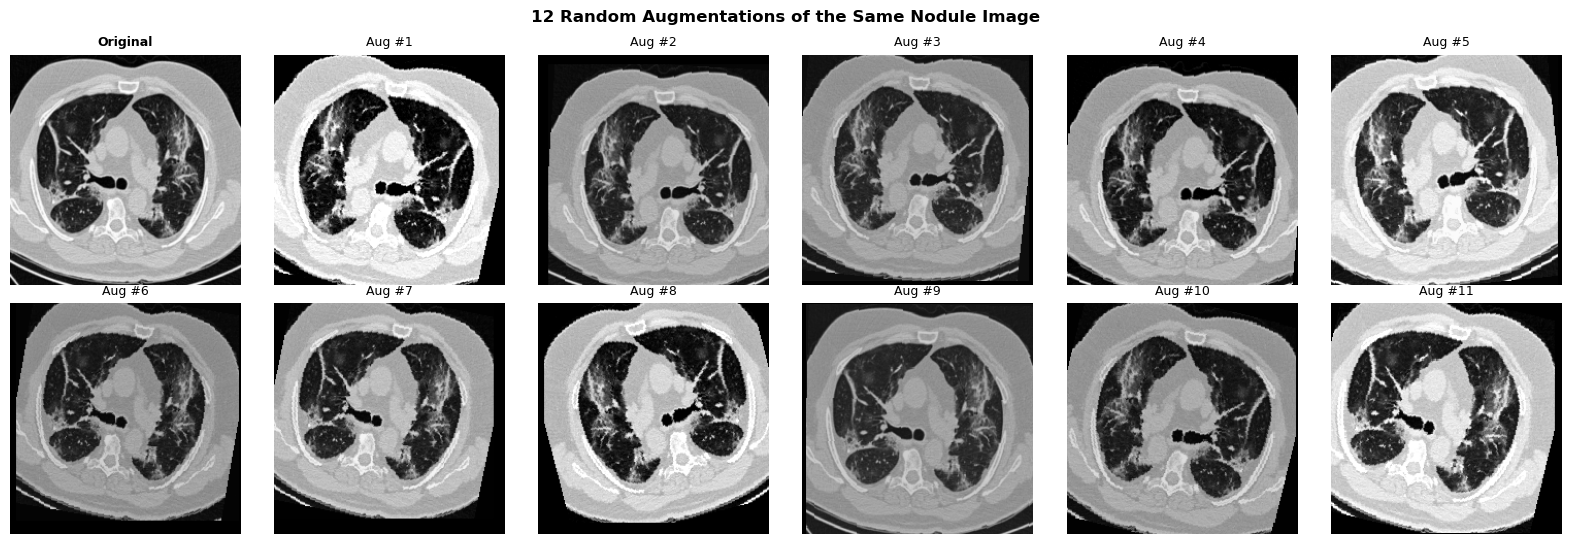

In [20]:
nodule_row  = train_df[train_df['label'] == 1].iloc[0]
base_img    = Image.open(nodule_row['path']).convert('RGB')

fig, axes = plt.subplots(2, 6, figsize=(16, 5.5))
axes = axes.flatten()

orig = viz_transform(base_img)
axes[0].imshow(np.array(orig), cmap='gray')
axes[0].set_title('Original', fontsize=9, fontweight='bold')
axes[0].axis('off')

for i in range(1, 12):
    aug = train_transform(base_img)
    vis = denormalize(aug, MEAN, STD).permute(1, 2, 0).numpy()
    axes[i].imshow(vis, cmap='gray')
    axes[i].set_title(f'Aug #{i}', fontsize=9)
    axes[i].axis('off')

plt.suptitle('12 Random Augmentations of the Same Nodule Image', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'augmentation_showcase.png'), dpi=150, bbox_inches='tight')
plt.show()

### 10. DataLoader Speed Test

In [21]:
import time

print(f'Testing speed (batch_size={BATCH_SIZE}, workers={NUM_WORKERS})...')
start = time.time()
for i, (imgs, _) in enumerate(train_loader):
    imgs.to(DEVICE, non_blocking=True)
    if i == 9: break
elapsed = time.time() - start

print(f'10 batches in {elapsed:.2f}s  ({elapsed/10*1000:.1f} ms/batch)')
print(f'Est. full train epoch load time: {elapsed/10*len(train_loader):.1f}s')
print('Tip: if >5s/batch, increase num_workers or use persistent_workers=True.')

Testing speed (batch_size=16, workers=0)...
10 batches in 5.05s  (504.8 ms/batch)
Est. full train epoch load time: 450.8s
Tip: if >5s/batch, increase num_workers or use persistent_workers=True.


### 11. Save Config & Reusable Loader

In [22]:
config = {
    'img_size':    IMG_SIZE,
    'batch_size':  BATCH_SIZE,
    'num_workers': NUM_WORKERS,
    'seed':        SEED,
    'mean':        MEAN.tolist(),
    'std':         STD.tolist(),
    'class_weights': train_dataset.get_class_weights().tolist(),
    'n_train':     len(train_dataset),
    'n_val':       len(val_dataset),
    'n_test':      len(test_dataset),
    'n_classes':   2,
    'class_names': {'0': 'No Nodule', '1': 'Nodule'},
}

with open(os.path.join(DATA_PROC, 'config.json'), 'w') as f:
    json.dump(config, f, indent=2)

print('config.json saved:')
for k, v in config.items():
    print(f'  {k}: {v}')

config.json saved:
  img_size: 224
  batch_size: 16
  num_workers: 0
  seed: 42
  mean: [0.27310427517443897, 0.27310427517443897, 0.27310427517443897]
  std: [0.2402257328778638, 0.2402257328778638, 0.2402257328778638]
  class_weights: [0.9926429986953735, 1.0074669122695923]
  n_train: 14302
  n_val: 3065
  n_test: 3065
  n_classes: 2
  class_names: {'0': 'No Nodule', '1': 'Nodule'}


In [23]:
loaders_src = '''
import os, json
import pandas as pd
import torch
import torchvision.transforms as T
from torch.utils.data import DataLoader
from dataset import LIDCDataset

def get_loaders(data_proc_dir, batch_size=32, num_workers=2):
    with open(os.path.join(data_proc_dir, "config.json")) as f:
        cfg = json.load(f)

    mean, std, img_size = cfg["mean"], cfg["std"], cfg["img_size"]

    # Updated: Extracts the 2-element array from config and converts to a FloatTensor
    class_weights = torch.tensor(cfg["class_weights"], dtype=torch.float32)

    train_df = pd.read_csv(os.path.join(data_proc_dir, "train.csv"))
    val_df   = pd.read_csv(os.path.join(data_proc_dir, "val.csv"))
    test_df  = pd.read_csv(os.path.join(data_proc_dir, "test.csv"))

    train_tfm = T.Compose([
        T.Resize((img_size, img_size)),
        T.RandomHorizontalFlip(p=0.5),
        # T.RandomVerticalFlip(p=0.2) -> REMOVED to preserve medical anatomical reality
        T.RandomRotation(degrees=15),
        T.ColorJitter(brightness=0.2, contrast=0.2),
        T.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
        T.ToTensor(),
        T.Normalize(mean=mean, std=std),
    ])

    val_tfm = T.Compose([
        T.Resize((img_size, img_size)),
        T.ToTensor(),
        T.Normalize(mean=mean, std=std),
    ])

    train_loader = DataLoader(LIDCDataset(train_df, train_tfm), batch_size=batch_size,
                              shuffle=True,  num_workers=num_workers, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(LIDCDataset(val_df,   val_tfm),   batch_size=batch_size,
                              shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(LIDCDataset(test_df,  val_tfm),   batch_size=batch_size,
                              shuffle=False, num_workers=num_workers, pin_memory=True)

    # Updated return statement to pass class_weights
    return train_loader, val_loader, test_loader, class_weights, cfg
'''

with open(os.path.join(SRC, 'loaders.py'), 'w') as f:
    f.write(loaders_src)

print('Saved: src/loaders.py')
print('In notebooks 03/04 use:')
print('  from loaders import get_loaders')
print('  train_loader, val_loader, test_loader, class_weights, cfg = get_loaders(DATA_PROC)')

Saved: src/loaders.py
In notebooks 03/04 use:
  from loaders import get_loaders
  train_loader, val_loader, test_loader, class_weights, cfg = get_loaders(DATA_PROC)
